In [1]:
##############################################################################
# 1) IMPORTS AND INITIAL SETUP

import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import pandas as pd

# For splitting dataset and model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA

# For evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Deep learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout,
    Bidirectional, Attention, Input, LayerNormalization
)

In [2]:
!pip install shap

In [3]:
##############################################################################
# NEW: IMPORTS FOR DATA AUGMENTATION AND EXPLAINABILITY (SHAP)
##############################################################################
import random
# If running locally or on some platforms, uncomment to install shap:

import shap

In [4]:
##############################################################################
# 2) DATASET PATH
##############################################################################
# NOTE: This path should point to your Asthma Detection Dataset Version 2
dataset_path = '/kaggle/input/asthma-detection-dataset-version-2/Asthma Detection Dataset Version 2/Asthma Detection Dataset Version 2/'

# The five categories/folders we have in the dataset
categories = ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']

# Print out the list of categories
print("Categories:", categories)


Categories: ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']


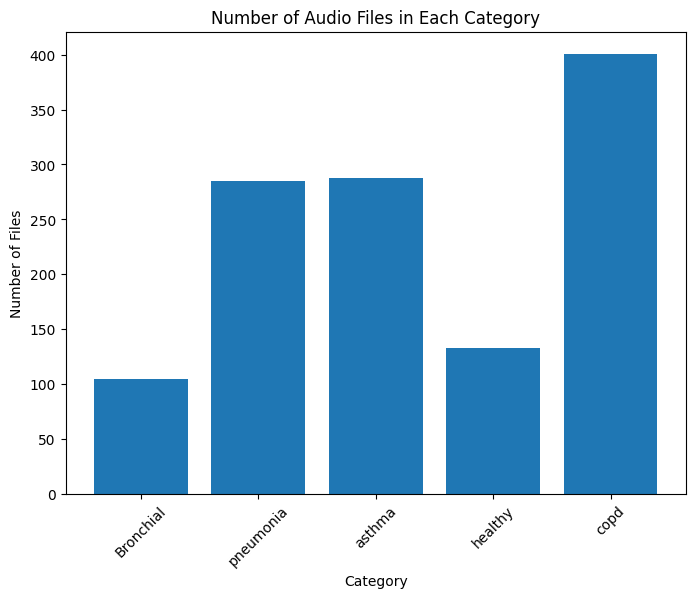

In [5]:
##############################################################################
# 3) BAR CHART: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Count how many .wav files exist in each category folder
category_counts = {
    category: len([
        f for f in os.listdir(os.path.join(dataset_path, category)) 
        if f.endswith('.wav')
    ])
    for category in categories
}

# Plot a bar chart of category counts
plt.figure(figsize=(8, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel('Category')
plt.ylabel('Number of Files')
plt.title('Number of Audio Files in Each Category')
plt.xticks(rotation=45)
plt.show()

In [6]:
##############################################################################
# 4) TABLE: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Create a PrettyTable to show the category counts
table = PrettyTable()
table.field_names = ["Category", "Number of Audio Files"]
for category, count in category_counts.items():
    table.add_row([category, count])

print("Number of Audio Files in Each Category:")
print(table)


Number of Audio Files in Each Category:
+-----------+-----------------------+
|  Category | Number of Audio Files |
+-----------+-----------------------+
| Bronchial |          104          |
| pneumonia |          285          |
|   asthma  |          288          |
|  healthy  |          133          |
|    copd   |          401          |
+-----------+-----------------------+



=== Waveform Examples for Each Category ===


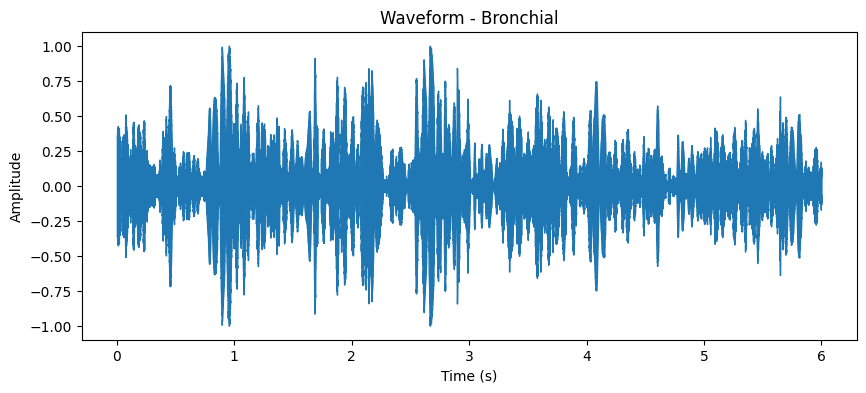

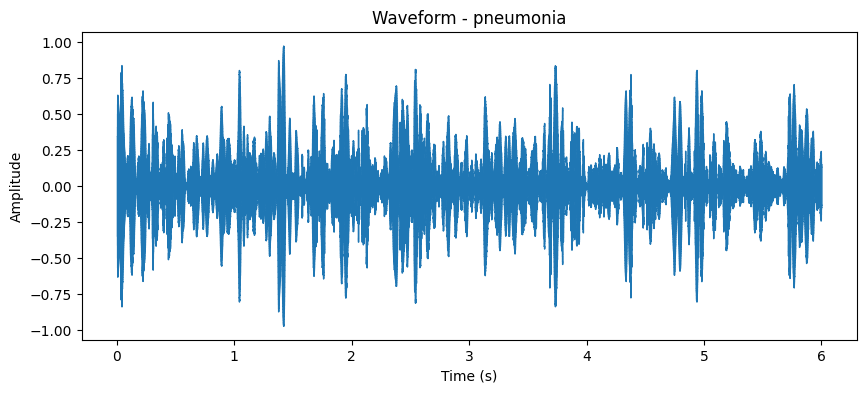

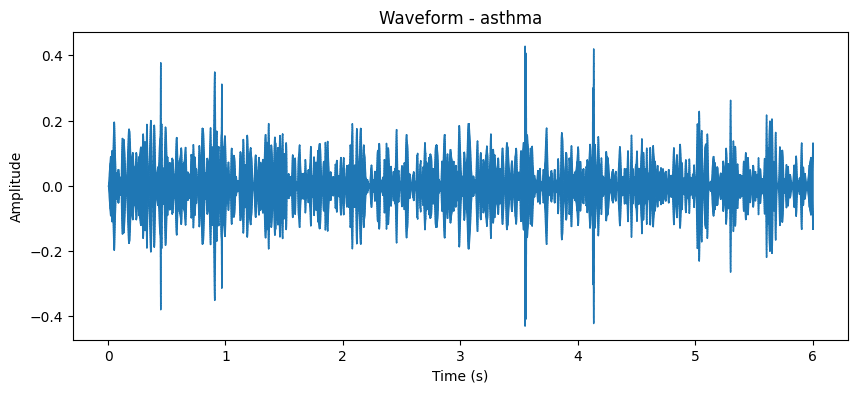

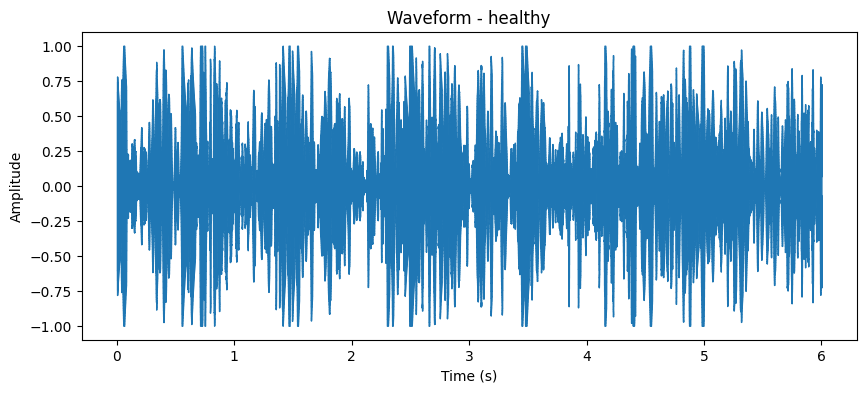

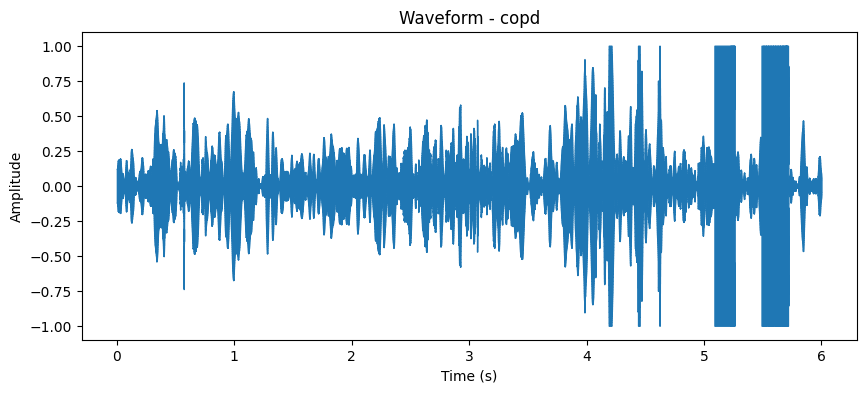

In [7]:
##############################################################################
# 5) SHOW 5 WAVEFORM PLOTS (ONE FROM EACH CATEGORY)
##############################################################################
# The user wants exactly 5 waveforms, one for each category.
# We will loop through the 5 categories, load the first audio in each folder,
# and plot the waveform using librosa.display.waveshow.
print("\n=== Waveform Examples for Each Category ===")
for i, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    if i < 5:  # just making sure we match exactly 5 categories
        if audio_files:
            audio_path = os.path.join(category_path, audio_files[0])
            y, sr = librosa.load(audio_path, sr=None)
            
            plt.figure(figsize=(10, 4))
            librosa.display.waveshow(y, sr=sr)
            plt.title(f'Waveform - {category}')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude')
            plt.show()

In [8]:
##############################################################################
# Fix 1) Rename local augmentation functions to avoid confusion
##############################################################################
def my_add_noise(audio, noise_factor=0.005):
    """Add random noise to the audio signal."""
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def my_time_stretch(audio, rate=1.0):
    """Time-stretch audio by a certain rate, using librosa's built-in function."""
    # Note: we explicitly call librosa.effects.time_stretch with y= and rate=
    return librosa.effects.time_stretch(y=audio, rate=rate)

def my_pitch_shift(audio, sr, n_steps=0):
    """Pitch-shift audio by n_steps semitones, using librosa's built-in function."""
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)

def augment_audio(y, sr):
    """
    Randomly apply one or more transformations to the audio
    to improve dataset variability.
    """
    import random
    choice = random.choice(['noise', 'stretch', 'pitch', 'none'])
    
    if choice == 'noise':
        return my_add_noise(y)
    elif choice == 'stretch':
        rate = random.uniform(0.8, 1.2)   # random stretch factor
        return my_time_stretch(y, rate=rate)
    elif choice == 'pitch':
        steps = random.uniform(-2, 2)     # random pitch shift in semitones
        return my_pitch_shift(y, sr, n_steps=steps)
    else:
        return y  # no augmentation


In [9]:
#############################################################################
# NEW: DATA AUGMENTATION + HANDLING CLASS IMBALANCE
# We'll find the largest category count and oversample the others by 
# generating augmented audio until each category matches the largest count.
##############################################################################
print("\n=== Data Augmentation and Class Balancing ===")
max_count = max(category_counts.values())

all_audio_data = []   # Will store (audio_array, sr, label)
for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    current_count = len(audio_files)
    
    # Load original audio
    loaded_signals = []
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_load, sr_load = librosa.load(audio_path, sr=None)
        loaded_signals.append((y_load, sr_load))
        all_audio_data.append((y_load, sr_load, category))
    
    # If category is underrepresented, generate augmented samples
    if current_count < max_count:
        needed = max_count - current_count
        # Randomly augment from existing signals
        for _ in range(needed):
            # pick a random original signal
            orig_y, orig_sr = random.choice(loaded_signals)
            # apply augmentation
            y_aug = augment_audio(orig_y, orig_sr)
            all_audio_data.append((y_aug, orig_sr, category))

# Now we have an augmented list "all_audio_data" 
# with all categories having the same number of samples.


=== Data Augmentation and Class Balancing ===


In [10]:
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC MEAN FEATURES)
##############################################################################
# We'll now extract features for the classification model.
print("\n=== Preparing Features and Labels for Model ===")
feature_list = []
labels_list = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_data, sr_data = librosa.load(audio_path, sr=None)
        # Extract MFCC (13)
        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)
        # Take mean across time frames
        feature_list.append(np.mean(mfcc_data, axis=1))
        labels_list.append(category)

X = np.array(feature_list)
y = np.array(labels_list)

print("Total Samples:", len(feature_list))
print("Feature Shape:", X.shape)



=== Preparing Features and Labels for Model ===


n_fft=2048 is too large for input signal of length=1920


Total Samples: 1211
Feature Shape: (1211, 13)


In [11]:
##############################################################################
# 19) LABEL ENCODING
##############################################################################
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print("Labels Shape:", y_encoded.shape)

Labels Shape: (1211,)


In [12]:
##############################################################################
# 20) TRAIN-TEST SPLIT (80/20) AS REQUESTED
##############################################################################
# We will specifically do 80/20, as per your preference (test_size=0.2).
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 968
Testing Samples: 243


In [13]:
##############################################################################
# 21) RESHAPE FOR LSTM (SAMPLES, TIMESTEPS, 1)
##############################################################################
# LSTM expects 3D input: (batch_size, timesteps, channels).
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [14]:
##############################################################################
# 22) BUILD AND COMPILE THE LSTM MODEL (RETENTION OF ORIGINAL STRUCTURE)
##############################################################################
model = Sequential()

model.add(
    Conv1D(
        filters=32, kernel_size=3, activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    Conv1D(
        filters=64, kernel_size=3, activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 11, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 9, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 4, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 4, 64)               │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 76,869 (300.27 KB)

 Trainable params: 76,869 (300.27 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.3296 - loss: 1.5122 - val_accuracy: 0.4948 - val_loss: 1.3460
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5036 - loss: 1.2783 - val_accuracy: 0.5258 - val_loss: 1.0854
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5182 - loss: 1.1116 - val_accuracy: 0.5825 - val_loss: 1.0031
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5653 - loss: 1.0475 - val_accuracy: 0.4588 - val_loss: 1.1508
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5692 - loss: 1.0536 - val_accuracy: 0.5773 - val_loss: 1.0366
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5883 - loss: 0.9608 - val_accuracy: 0.6082 - val_loss: 0.8593
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6560 - loss: 0.8626 - val_accuracy: 0.6546 - val_loss: 0.8560
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7101 - loss: 0.7523 - val_accuracy: 0.6856 - val_loss

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Model Performans Metrikleri:
Accuracy: 0.8436
Precision: 0.8605
Recall: 0.8436
F1-Score: 0.8444

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        20
           1       0.71      0.91      0.80        57
           2       0.97      0.89      0.93        74
           3       0.84      0.78      0.81        27
           4       0.83      0.83      0.83        65

    accuracy                           0.84       243
   macro avg       0.87      0.80      0.82       243
weighted avg       0.86      0.84      0.84       243



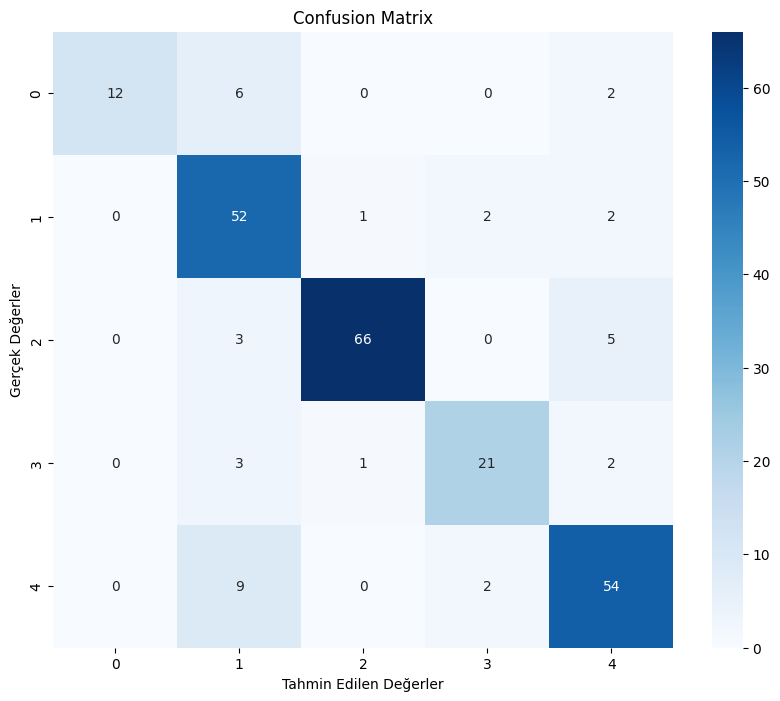

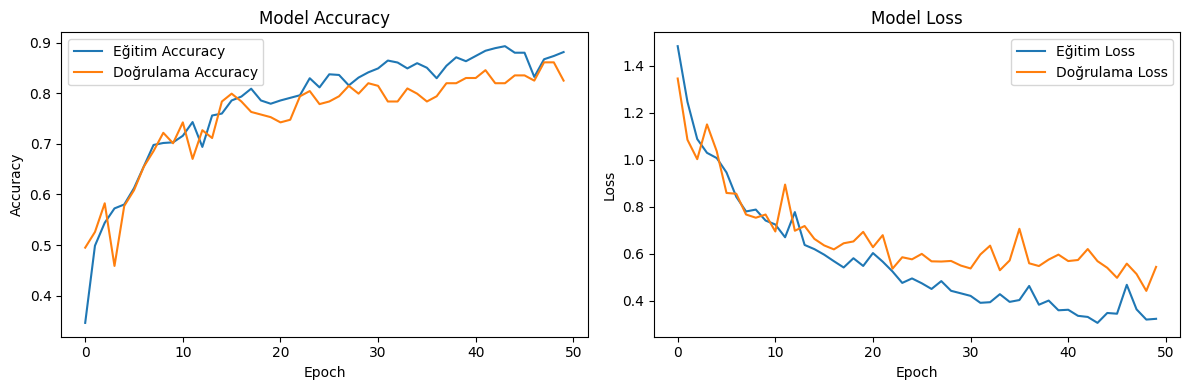

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrikleri hesapla
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Sonuçları yazdır
print("\nModel Performans Metrikleri:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detaylı sınıflandırma raporu
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix için
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix oluştur
cm = confusion_matrix(y_test, y_pred_classes)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Eğitim sürecindeki accuracy ve loss değerlerinin grafiğini çiz
plt.figure(figsize=(12, 4))

# Accuracy grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Doğrulama Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.


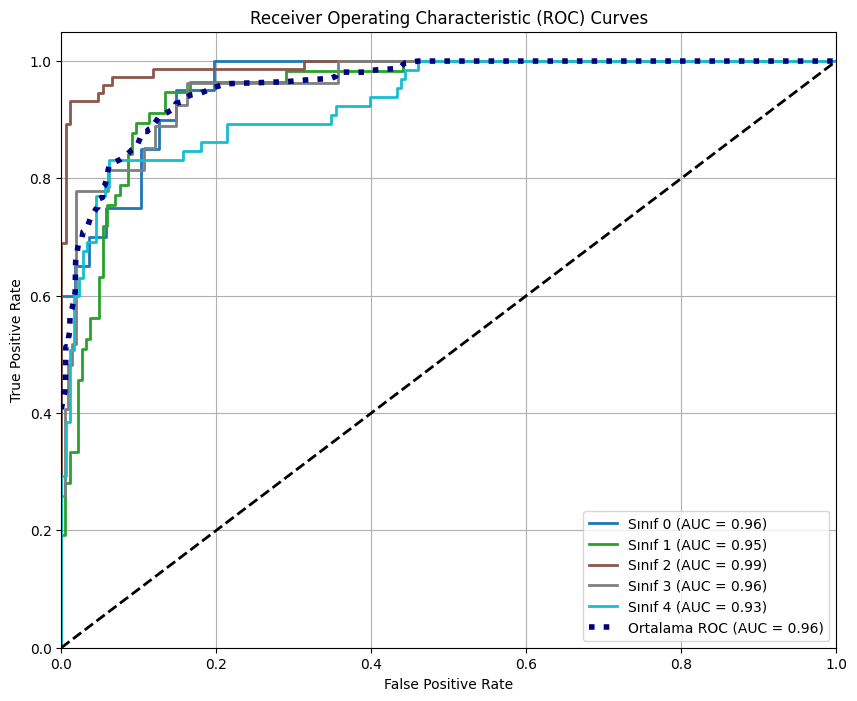


AUC Değerleri:
Sınıf 0: 0.9605
Sınıf 1: 0.9484
Sınıf 2: 0.9902
Sınıf 3: 0.9580
Sınıf 4: 0.9309
Ortalama AUC: 0.9588


In [17]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def plot_roc_curves(y_test, y_pred_proba):
    """
    Çok sınıflı ROC eğrilerini çizer

    Parametreler:
    y_test: Gerçek etiketler
    y_pred_proba: Model tahmin olasılıkları
    """

    # Sınıf sayısını belirle
    n_classes = y_pred_proba.shape[1]

    # Her sınıf için ROC eğrisi
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # One-hot encoding yap
    y_test_bin = np.eye(n_classes)[y_test]

    # Her sınıf için ROC eğrisi hesapla
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Ortalama ROC eğrisi hesapla
    fpr_mean = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    tpr_mean = np.zeros_like(fpr_mean)
    for i in range(n_classes):
        tpr_mean += np.interp(fpr_mean, fpr[i], tpr[i])
    tpr_mean = tpr_mean / n_classes

    fpr["macro"] = fpr_mean
    tpr["macro"] = tpr_mean
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # ROC eğrilerini çiz
    plt.figure(figsize=(10, 8))

    # Her sınıf için ROC eğrisi
    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'Sınıf {i} (AUC = {roc_auc[i]:.2f})')

    # Ortalama ROC eğrisi
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Ortalama ROC (AUC = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)

    # Referans çizgisi
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return roc_auc

# Model tahminlerini al
y_pred_proba = model.predict(X_test)

# ROC eğrilerini çiz ve AUC değerlerini al
roc_auc_scores = plot_roc_curves(y_test, y_pred_proba)

# AUC değerlerini yazdır
print("\nAUC Değerleri:")
for i in range(len(np.unique(y_test))):
    print(f"Sınıf {i}: {roc_auc_scores[i]:.4f}")
print(f"Ortalama AUC: {roc_auc_scores['macro']:.4f}")

In [18]:
##############################################################################
# 21) RESHAPE FOR LSTM (SAMPLES, TIMESTEPS, 1)
##############################################################################
# LSTM expects 3D input: (batch_size, timesteps, channels).
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1])

In [19]:
model = Sequential()

model.add(Conv1D(filters=32, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], 1), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))

model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 13, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 6, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 6, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 3, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 3, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,013 (74.27 KB)

 Trainable params: 19,013 (74.27 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.2533 - loss: 12.6332 - val_accuracy: 0.2938 - val_loss: 1.9771
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3246 - loss: 4.1636 - val_accuracy: 0.3814 - val_loss: 1.7168
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3373 - loss: 2.0777 - val_accuracy: 0.5206 - val_loss: 1.1716
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3893 - loss: 1.6232 - val_accuracy: 0.6082 - val_loss: 1.0852
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4637 - loss: 1.3557 - val_accuracy: 0.5773 - val_loss: 1.0242
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5387 - loss: 1.2152 - val_accuracy: 0.6082 - val_loss: 0.9620
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5583 - loss: 1.1093 - val_accuracy: 0.6031 - val_loss: 0.9844
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5635 - loss: 1.0841 - val_accuracy: 0.6443 - val_los

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

Model Performans Metrikleri:
Accuracy: 0.8230
Precision: 0.8245
Recall: 0.8230
F1-Score: 0.8215

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72        20
           1       0.76      0.89      0.82        57
           2       0.97      0.95      0.96        74
           3       0.67      0.59      0.63        27
           4       0.78      0.77      0.78        65

    accuracy                           0.82       243
   macro avg       0.80      0.77      0.78       243
weighted avg       0.82      0.82      0.82       243



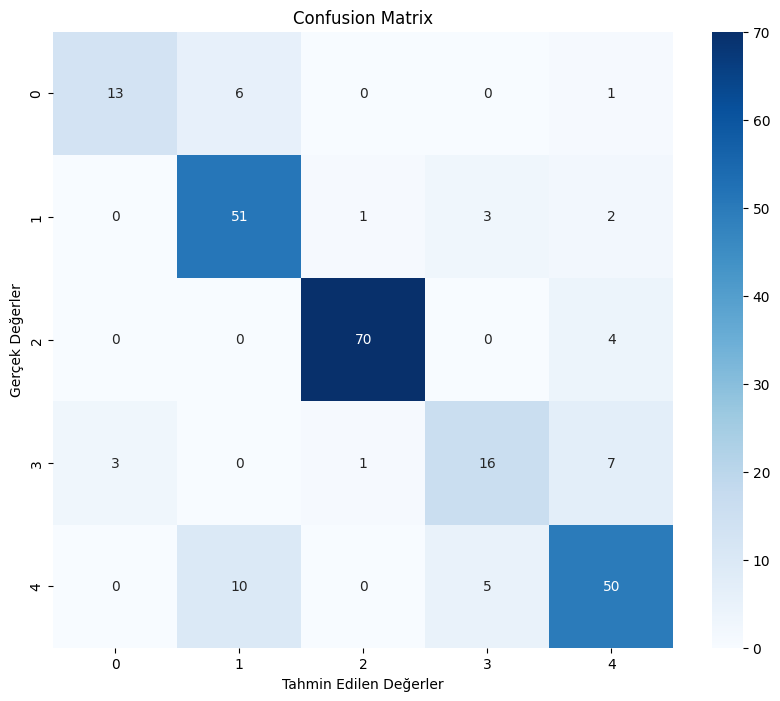

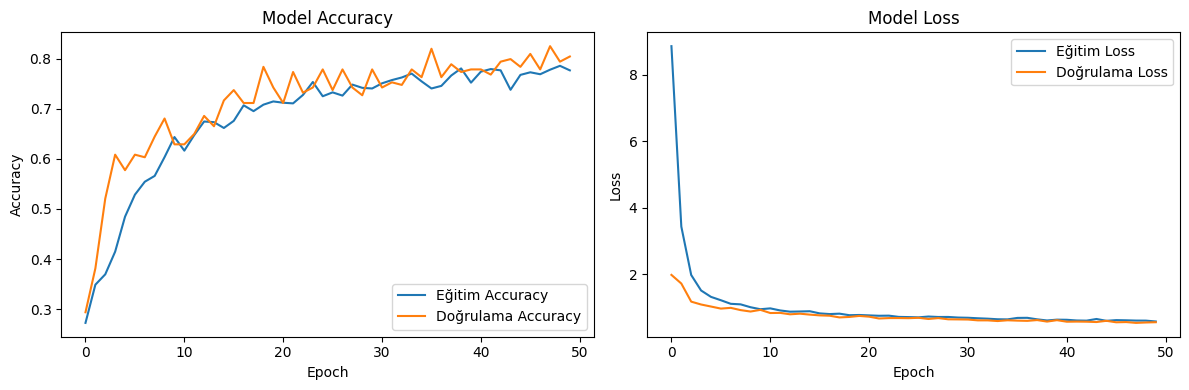

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrikleri hesapla
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Sonuçları yazdır
print("\nModel Performans Metrikleri:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detaylı sınıflandırma raporu
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix için
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix oluştur
cm = confusion_matrix(y_test, y_pred_classes)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Eğitim sürecindeki accuracy ve loss değerlerinin grafiğini çiz
plt.figure(figsize=(12, 4))

# Accuracy grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Doğrulama Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# sadece cnn kullanınca daha iyi sonuç verdi